<a href="https://colab.research.google.com/github/kirat-anand-68/NEURAL_NETWORKS/blob/main/MNISTDIGITS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing The Dependency
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

In [2]:
# Loading the mnist data from keras.datasets
(X_train,y_train),(X_test,y_test)= mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
type(X_train)

numpy.ndarray

In [4]:
# Shape of the numpy arrays
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [ ]:
# training data = 60,000 images
# test data = 100000 images
# images dimesions = 28*28
# grayscale = 1 color Channel


In [5]:
# printing the tenth image from the x train
print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [6]:
print(X_train[10].shape)

(28, 28)


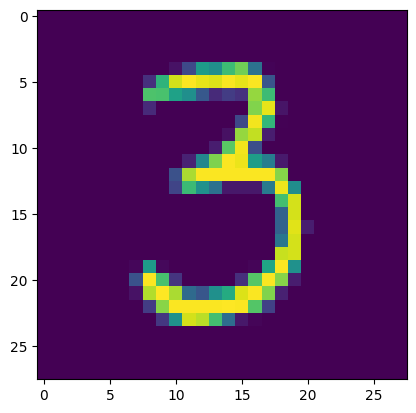

3


In [7]:
# displaying the image
plt.imshow(X_train[50])
plt.show()

# print the corresponding label
print(y_train[50])

In [8]:
# Images Label

print(y_train.shape, y_test.shape)

(60000,) (10000,)


In [9]:
# unique values in y_train
print(np.unique(y_train))
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [10]:
# We can use this labels as such or we can also apply the one hot encoding
# All the images have the same dimensions in dataset if not we have to resixe the images in the common dimensions
# scaling the values.

X_train=X_train/255
X_test=X_test/255

In [11]:
print(X_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [12]:
# Building the neural network

# setting up the layers of the neural network
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50, activation="relu"),
    keras.layers.Dense(50, activation="relu"),
    keras.layers.Dense(10,activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
# compiling the neural network
model.compile(optimizer="Adam",
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
# training the neural network
model.fit(X_train,y_train,epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9122 - loss: 0.3032
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9575 - loss: 0.1418
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9685 - loss: 0.1039
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9751 - loss: 0.0820
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9798 - loss: 0.0672
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9829 - loss: 0.0557
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9852 - loss: 0.0474
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9875 - loss: 0.0401
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9884 - loss: 0.0353
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9903 - loss: 0.0301
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9901 - loss: 0.0275
Epoch 12/15
1875/1875 ━━━━━━━━

In [15]:
# training data accuracy is 98.78%
# accuracy on test data
loss,accuracy = model.evaluate(X_test, y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9661 - loss: 0.1478
0.9660999774932861


In [16]:
# test data accuracy if 96.6%

print(X_test.shape)

(10000, 28, 28)


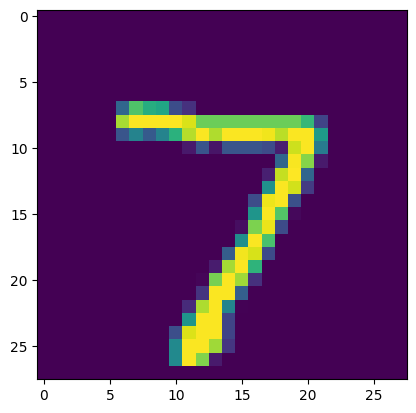

In [17]:
# display the first data point
plt.imshow(X_test[0])
plt.show()

In [18]:
print(y_test[0])

7


In [19]:
y_pred= model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [20]:
print(y_pred.shape)

(10000, 10)


In [21]:
print(y_pred[0])

[5.4046948e-05 3.6082111e-02 7.4250787e-02 4.9961093e-01 1.3655064e-03
 1.5014464e-05 4.0135470e-14 1.0000000e+00 6.4069657e-03 5.8726311e-01]


In [22]:
# model.predict() the prediction probability of each class for that data point

# converting the prediction probabilite=ies to class label
label_for_first_image=np.argmax(y_pred[0])

In [23]:
print(label_for_first_image)

7


In [24]:
# aegmax used to tell the index of the max array
# converting teh prediction probability into class label for all test data points
y_pred_label=[np.argmax(i) for i in y_pred ]
print(y_pred_label)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

In [25]:
print(y_pred)

[[5.4046948e-05 3.6082111e-02 7.4250787e-02 ... 1.0000000e+00
  6.4069657e-03 5.8726311e-01]
 [7.3135793e-01 1.0663476e-01 1.0000000e+00 ... 3.3248059e-04
  5.0667415e-05 2.0093522e-20]
 [2.8526840e-05 9.9998319e-01 1.2293261e-01 ... 5.2682233e-01
  5.6007981e-01 7.7355748e-05]
 ...
 [3.4174660e-11 4.1521902e-04 2.2113261e-05 ... 9.8902202e-01
  1.1168385e-03 1.0280932e-02]
 [7.2454725e-08 2.0678335e-07 2.1081433e-12 ... 2.8246327e-06
  9.8622251e-01 9.7815902e-04]
 [7.9614294e-01 4.3910133e-09 6.1122691e-03 ... 1.2580613e-12
  2.5018448e-06 1.2356472e-07]]


In [27]:
# y_test are true labels and the y_pred are the Predicted label as their represenatation

# ConfudionMatrix
conf_mat = confusion_matrix(y_test,y_pred_label)


In [28]:
print(conf_mat)

tf.Tensor(
[[ 960    1    0    1    2    2    5    2    2    5]
 [   0 1116    3    2    4    0    2    0    6    2]
 [   3    2  994    5    3    0    2   10   13    0]
 [   1    0    6  977    0    3    0    4    9   10]
 [   0    0    3    0  970    0    2    0    0    7]
 [   4    0    0   51    0  818    3    1   10    5]
 [   5    4    3    0   14    3  924    0    5    0]
 [   1    3    8    1    4    0    0  997    1   13]
 [   3    0    3    7    8    2    3    3  936    9]
 [   1    2    1    6   21    5    0    2    2  969]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted Labels')

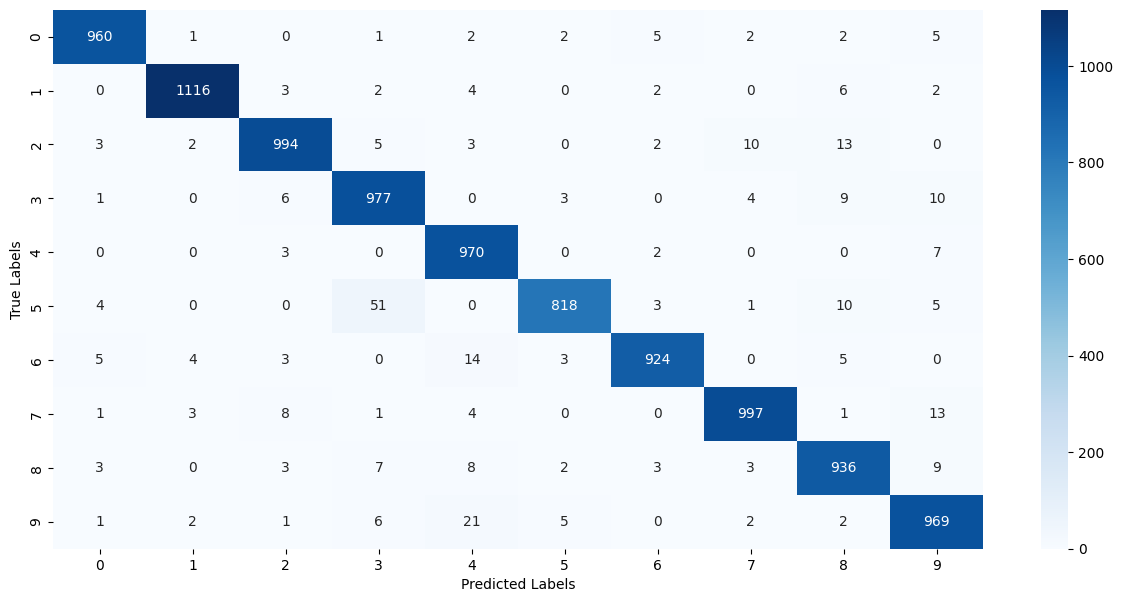

In [29]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat,annot=True, fmt='d',cmap="Blues")
plt.ylabel('True Labels')
plt.xlabel("Predicted Labels")

In [30]:
 # Building the preditive system
input_image_path='/content/4.jpg'
input_image = cv2.imread(input_image_path)

In [31]:
type(input_image)

numpy.ndarray

In [32]:
print(input_image)

[[[236 236 236]
  [138 138 138]
  [158 158 158]
  ...
  [162 162 162]
  [162 162 162]
  [163 163 163]]

 [[143 143 143]
  [ 14  14  14]
  [ 12  12  12]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[159 159 159]
  [  4   4   4]
  [  0   0   0]
  ...
  [  1   1   1]
  [  2   2   2]
  [  2   2   2]]

 ...

 [[158 158 158]
  [ 15  15  15]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[112 112 112]
  [ 13  13  13]
  [  0   0   0]
  ...
  [  1   1   1]
  [  1   1   1]
  [  1   1   1]]

 [[255 255 255]
  [223 223 223]
  [226 226 226]
  ...
  [232 232 232]
  [232 232 232]
  [232 232 232]]]


In [34]:
import cv2

In [36]:
import cv2
from google.colab.patches import cv2_imshow

input_image = cv2.imread("/content/image.jpg")

cv2_imshow(input_image)

AttributeError: 'NoneType' object has no attribute 'clip'

In [37]:
import os

os.listdir('/content')

['.config', '4.jpg', 'sample_data']

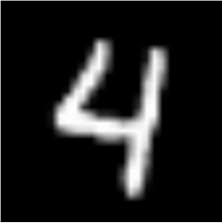

In [38]:
import cv2
from google.colab.patches import cv2_imshow

input_image = cv2.imread('/content/4.jpg')

cv2_imshow(input_image)

In [39]:
input_image.shape

(223, 222, 3)

In [40]:
grayscale=cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

In [41]:
C

(223, 222)

In [47]:
input_image_resize=cv2.resize(grayscale,(28,28))

In [48]:
input_image_resize.shape

(28, 28)

In [49]:


cv2_imshow(input_image_resize)

In [50]:
input_image_resize=input_image_resize/255

In [52]:
image_reshaped=np.reshape(input_image_resize,[1,28,28])

In [53]:
input_prediction = model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[1.6296970e-05 2.0928897e-01 1.8963271e-03 1.2000623e-06 1.0000000e+00
  1.8287067e-04 7.4433815e-06 4.4346249e-01 2.9997819e-04 6.9430375e-01]]


In [54]:
input_pred_label=np.argmax(input_prediction)

In [55]:
print(input_pred_label)

4


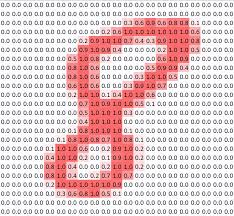

In [67]:
import cv2
from google.colab.patches import cv2_imshow

input_image_new = cv2.imread('/content/8.jpg')

cv2_imshow(input_image_new)

In [68]:
input_image_new.shape

(216, 234, 3)

In [69]:
grayscale=cv2.cvtColor(input_image_new, cv2.COLOR_RGB2GRAY)

In [70]:
input_image_resize_new=cv2.resize(grayscale,(28,28))

In [71]:
image_reshaped_new=np.reshape(input_image_resize_new,[1,28,28])

In [76]:
input_prediction = model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[2.7579516e-22 5.0919518e-14 1.6942432e-03 1.0000000e+00 0.0000000e+00
  9.9999964e-01 2.5192123e-38 6.8533293e-05 2.1952022e-22 1.4166535e-22]]


In [77]:
input_pred_label=np.argmax(input_prediction)

In [73]:
cv2_imshow(input_image_resize_new)

In [72]:
input_image_resize_new.shape

(28, 28)

In [74]:
input_image_resized=input_image_resize_new/255

In [75]:
image_reshaped=np.reshape(input_image_resized,[1,28,28])

In [78]:
print(input_pred_label)

3


Path of the image to be predicted: /content/4.jpg


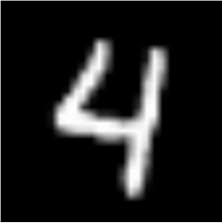

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
The Handwritten Digit is recognised as: 4


In [82]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Input image path
input_image_path = input('Path of the image to be predicted: ')

# Read image
input_image = cv2.imread(input_image_path)

# Show image
cv2_imshow(input_image)

# Convert to grayscale
grayscale = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

# Resize image to 28x28
input_image_resize_new = cv2.resize(grayscale, (28, 28))

# Normalize
input_image_resized = input_image_resize_new / 255.0

# Reshape for model
image_reshaped = np.reshape(input_image_resized, [1, 28, 28])

# Prediction
input_prediction = model.predict(image_reshaped)

# Predicted label
input_pred_label = np.argmax(input_prediction)

print('The Handwritten Digit is recognised as:', input_pred_label)